# Advanced Generative Models Compared (StyleGAN, Stable Diffusion, DALL-E)

## 📚 Learning Objectives

By completing this notebook, you will:
- Describe what distinguishes StyleGAN, Stable Diffusion, and DALL-E architecturally
- Compare the three families on conditioning, quality, control, and access
- Ground the concepts by training a small GAN locally and connecting it to each family
- Know how to reach the real models (open weights vs APIs) for your own experiments

## 🔗 Prerequisites

- ✅ GAN training basics (Unit 1)
- ✅ Diffusion-model basics (Unit 3)

---

This notebook covers practical activities from **Course 10, Unit 5**:
- Experimenting with advanced generative models (StyleGAN, Stable Diffusion, DALL-E)

---

## Introduction

**Advanced generative models** like StyleGAN, Stable Diffusion, and DALL-E represent the
state of the art in image generation.

**Honest scope note:** these models need GPUs, multi-GB weight downloads, or paid APIs — too heavy
for a classroom notebook. So here we (1) compare the three families properly, and (2) train a
small GAN on MNIST *locally* — the same adversarial core StyleGAN scales up — then point you to
the real models for at-home experimentation.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# WHAT/WHY: quick tour of the three model families (StyleGAN, Stable
# Diffusion, DALL-E) that the toy-scale experiments below imitate.
print("✅ Libraries imported!")
print("\nAdvanced Generative Models")
print("=" * 60)

print("\nStyleGAN:")
print("  - High-quality image generation")
print("  - Style-based architecture")
print("  - Latent space control")
print("  - Progressive growing")

print("\nStable Diffusion:")
print("  - Text-to-image")
print("  - Open-source")
print("  - Diffusion model")
print("  - High quality")

print("\nDALL-E:")
print("  - OpenAI model")
print("  - Text-to-image")
print("  - Creative generation")
print("  - API access")

print("\n✅ Advanced generative models concepts understood!")

✅ Libraries imported!

Advanced Generative Models

StyleGAN:
  - High-quality image generation
  - Style-based architecture
  - Latent space control
  - Progressive growing

Stable Diffusion:
  - Text-to-image
  - Open-source
  - Diffusion model
  - High quality

DALL-E:
  - OpenAI model
  - Text-to-image
  - Creative generation
  - API access

✅ Advanced generative models concepts understood!


## The Three Families, Side by Side

| | **StyleGAN (2/3/XL)** | **Stable Diffusion** | **DALL-E (2/3)** |
|---|---|---|---|
| Core mechanism | GAN — generator vs discriminator | Latent diffusion — iterative denoising | Diffusion + CLIP/transformer priors |
| Conditioning | Latent style vectors (no text) | Text prompt (CLIP embedding) | Text prompt |
| Signature strength | Photoreal faces; smooth latent control | Open weights; runs on consumer GPUs | Prompt fidelity; ease of use |
| Control mechanism | Style mixing per layer | Prompt + guidance scale + LoRA/ControlNet | Prompt (+ limited API params) |
| Access | Open weights (NVIDIA research) | Open weights (Hugging Face `diffusers`) | Paid API only (OpenAI) |
| Relation to today's demo | Same adversarial loss, scaled ~10,000x | Different mechanism — see Unit 3's DDPM demo | Different mechanism + text encoder |

**Try the real ones at home:**

- *Stable Diffusion* (open, needs a GPU): the `diffusers` library —
  `StableDiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-2-1")`
- *StyleGAN3* pretrained faces: NVIDIA's official GitHub release
- *DALL-E 3*: via the OpenAI Images API (paid)

Below, the hands-on part: the adversarial core of the GAN family, small enough to train here.

## 🌍 Hands-On — the GAN Core That StyleGAN Scales Up

**Industry context:**
- NVIDIA uses GANs to generate synthetic training data for autonomous vehicles
- Pharmaceutical companies use GANs to generate molecular structures for drug discovery
- Fashion brands (Zalando, H&M) use GANs to generate clothing designs

We train a **small fully-connected GAN** (linear layers only — StyleGAN's generator adds
convolutions, progressive resolution, and per-layer style injection on top of this exact
adversarial recipe) to generate handwritten digits from pure noise.

Epoch 1/10 — D loss: 0.678  G loss: 1.527


Epoch 2/10 — D loss: 0.724  G loss: 1.704


Epoch 3/10 — D loss: 0.560  G loss: 3.035


Epoch 4/10 — D loss: 0.471  G loss: 2.929


Epoch 5/10 — D loss: 0.280  G loss: 3.017


Epoch 6/10 — D loss: 0.359  G loss: 2.719


Epoch 7/10 — D loss: 0.996  G loss: 5.652


Epoch 8/10 — D loss: 0.664  G loss: 2.155


Epoch 9/10 — D loss: 0.669  G loss: 2.707


Epoch 10/10 — D loss: 0.756  G loss: 1.615


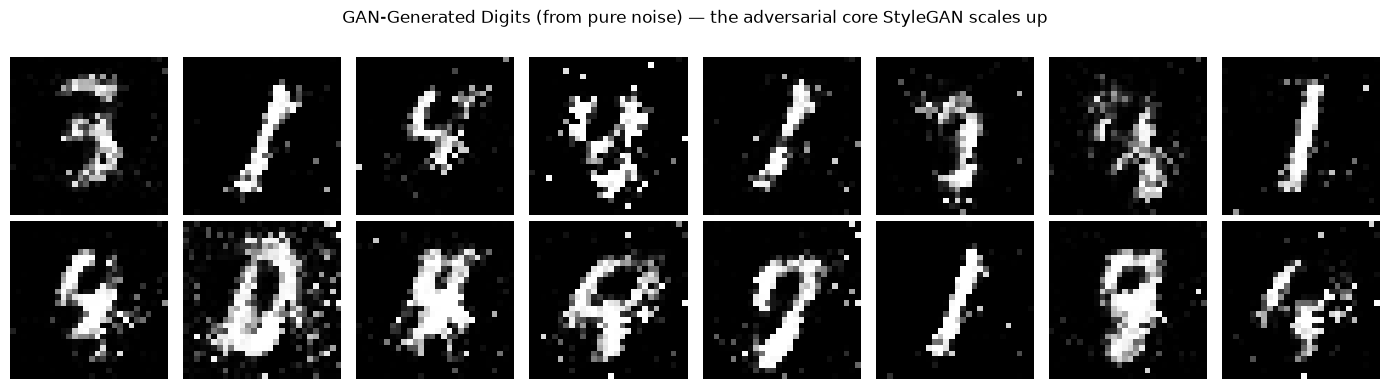

In [2]:
# Train a small fully-connected GAN on MNIST — the adversarial core of the GAN family.
# WHY: generator vs discriminator with BCE loss is exactly what StyleGAN scales up;
# training it yourself makes the comparison table above concrete.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

transform = T.Compose([T.ToTensor(), T.Normalize([0.5],[0.5])])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: noise → image ───────────────────────────────────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: image → real/fake ─────────────────────────────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
bce   = nn.BCELoss()

d_losses, g_losses = [], []
for epoch in range(10):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # ── Train Discriminator ─────────────────────────────────────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs,1)) + bce(D(fake), torch.zeros(bs,1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── Train Generator ─────────────────────────────────────────────
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs,1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    d_losses.append(loss_D.item()); g_losses.append(loss_G.item())
    print(f"Epoch {epoch+1}/10 — D loss: {d_losses[-1]:.3f}  G loss: {g_losses[-1]:.3f}")

# ── Show generated images ──────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    samples = G(torch.randn(16, LATENT_DIM)).view(16, 28, 28).numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray'); ax.axis('off')
plt.suptitle("GAN-Generated Digits (from pure noise) — the adversarial core StyleGAN scales up")
plt.tight_layout(); plt.show()

## 📝 Summary

In this notebook, you:

- Compared **StyleGAN, Stable Diffusion, and DALL-E** across mechanism, conditioning, control,
  and access — and saw why only one of the three (Stable Diffusion) has open weights
- Trained a small **GAN locally** and connected its adversarial recipe to what StyleGAN scales up
- Collected concrete entry points (`diffusers`, StyleGAN3 releases, OpenAI API) for experimenting
  with the real models on your own hardware

**Honest scope note:** we did not run the three large models here — they require GPUs or paid
APIs; what you ran is the small-scale core of the GAN family plus Unit 3's diffusion demo.

## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(invented GANs)*
- Radford et al. (2015) — [DCGAN](https://arxiv.org/abs/1511.06434)
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958)

**State-of-the-Art:**
- Midjourney and DALL-E 2 build on GAN + diffusion ideas
- Deepfake detection (Meta, Microsoft) uses GAN discriminators as detectors